In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Core imports
import pandas as pd
import matplotlib.pyplot as plt

# Sklearn imports
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Project-specific utilities
from process_bank_churn import preprocess_data, create_preprocessor, preprocess_new_data
from custom_features import get_custom_pipelines
from plot_utils import plot_roc_curve, print_main_metrics, plot_feature_importances


В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням Decision Trees і зробимо новий submission на змагання на Kaggle.

В цьому ДЗ ми працюємо без pipelines, бо так буде зручніше для візуалізації і інтерпретації моделі дерева прийняття рішень. Так буває і в робочих проєктах: іноді зручніше використати sklearn.Pipelines, іноді зручніше без них. На етапі пошуку рішення (research) зручніше без пайплайнів, а з пайплайнами - коли ви відлагодили процес обробки даних і хочете поекспериментувати з різними моделями і гіперпараметрами.

**Завдання 1.**

У попередньому домашньому завданні, `HW 2.7 Логістична регресія з scikit learn.ipynb`, ми писали обробку даних для змагання. Ваше завдання зараз - за прикладом, наведеним в лекції `Майстер-клас з перенесення коду з jupyter notebook у Python модуль`, перенести попередню обробку сирих даних з вашого розв'язку ДЗ 2.7 у файл `process_bank_churn.py` в функцію `preprocess_data(...)`.

Функція `preprocess_data()` має приймати `raw_df` і вертати `X_train`, `train_targets`, `X_val`, `val_targets`, `input_cols`(перелік назв колонок, які Ви використовуєте в X), `scaler`, `encoder`, які ми потім будемо використовувати для тренування дерева прийняття рішень.


### Кроки попередньої обробки:

1. Обираємо колонки для роботи. В цьому завдання для чистоти експериментів рекомендую прибрати колонку `Surname`, так буде простіше інтрепретувати модель. Ви можете її додати вже за самостійних подальших експериментів.
2. Розбиття сирих даних на тренувальні і валідаційні.
3. Обробка категоріальних даних (one hot encoding).
4. Масштабування числових даних (було частиною попередньої обробки в попередніх завданнях). Для дерев нам не обовʼязково масштабувати ознаки, тож в коді можна зробити цю частину опціональною, додавши в `preprocess_data` параметр `scaler_numeric`, який приймає значення `True` або `False`. Це дозволить використовувати код попередньоъ обробки з різними моделями.


### Інструкції:
1. Перенесіть попередню обробку даних у файл `process_bank_churn.py`.
2. Забезпечте модулярну структуру функцій: кожна функція повинна виконувати лише одну дію, наприклад, масштабувати ознаки.
3. Додайте докстрінги до кожної функції.
4. Використовуйте typing для аргументів та значень, що повертаються функціями.
5. Передбачте обробку нових даних. Додайте спеціальну функцію `preprocess_new_data(...)`, яка приймає на вхід нові дані в вигляді pandas DataFrame та використовує вже навчені скейлер та енкодер (передані теж як аргументи фукнціх) для їх обробки. Ця функція буде корисною для обробки нових даних перед передбаченням або оцінкою моделі, коли оброблятимемо `test.csv`.

Можна і рекомендовано виконувати це завдання з ChatGPT (бажано, новіше, ніж 3.5) як було наведено у відео-прикладі, тільки **ваше додаткове завдання - розібратись з кодом, який вам згенерувала мовна модель :)**.

## В результаті цього завдання

1. Завантажте ваш готовий `process_bank_churn.py` файл на GitHub у свій репозиторій.
2. Додайте посилання на файл в репозиторії тут у ноутбуці.
3. Нижче зробіть імпорт функції `preprocess_data` з вашого модуля `process_bank_churn.py`.



In [2]:
raw_df = pd.read_csv('../assets/hw_2_2/train.csv')

raw_df.nunique()

id                 15000
CustomerId          6348
Surname              764
CreditScore          378
Geography              3
Gender                 2
Age                   56
Tenure                11
Balance             3395
NumOfProducts          4
HasCrCard              2
IsActiveMember         2
EstimatedSalary     6242
Exited                 2
dtype: int64

In [3]:
numeric_cols = ['CreditScore', 'Balance', 'EstimatedSalary', 'Tenure']
categorical_cols = ['Geography', 'Gender', 'NumOfProducts']
target_enc_cols = ['NumOfProducts', 'Gender', 'Geography']

custom_pipelines = get_custom_pipelines()

preprocessor = create_preprocessor(numeric_cols, categorical_cols, target_enc_cols, custom_pipelines)

X_train, y_train, X_val, y_val, input_cols = preprocess_data(raw_df,
    preprocessor,
    "Exited",
    ["id", "CustomerId", "Surname", "Exited"]
)

print(X_train.head())
print(y_train.head())
print(input_cols)

       CreditScore    Balance  EstimatedSalary  Tenure  Geography_France  \
8263         696.0  130627.66         86786.41     5.0               1.0   
14199        632.0  119825.75        177737.04     4.0               0.0   
1856         679.0       0.00        162599.54     4.0               1.0   
3013         705.0       0.00        119814.25     3.0               1.0   
8266         696.0       0.00        100423.88     7.0               1.0   

       Geography_Germany  Geography_Spain  Gender_Male  NumOfProducts_1.0  \
8263                 0.0              0.0          1.0                1.0   
14199                1.0              0.0          0.0                1.0   
1856                 0.0              0.0          0.0                0.0   
3013                 0.0              0.0          1.0                0.0   
8266                 0.0              0.0          0.0                0.0   

       NumOfProducts_2.0  NumOfProducts_3.0  NumOfProducts_4.0  NumOfProducts  \

**Завдання 2.**
1. Натренуйте дерево прийняття рішень з зафіксованим `random_state` і з рештою аргументів за замовченням.
2. Виведіть area under ROC для моделі на тренувальних і тестувальних даних. Нам потрібна ця метрика, бо вона основна в змаганні. Модель ок, чи є пере- або недотренування?
3. Виведіть глибину дерева.
4. Побудуйте дерево до глибини 2 включно. Напишіть, які ознаки бачите, що є найвпливовішими тут?
5. Створіть датафрейм `importance_df` з feature importances, де в першому стовпчику `feature` - назва ознаки з нашого Х, а в другому `importance` - значення, наскільки ця ознака є важливою в побудованій моделі. Виведіть топ 10 найвпливовіших ознак разом з їх скором важливості (можна або у вигляді таблиці, або в вигляді barplot).

In [4]:
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

Train AUROC: 1.000
Train F1 score: 1.000
Validation AUROC: 0.755
Validation F1 score: 0.605


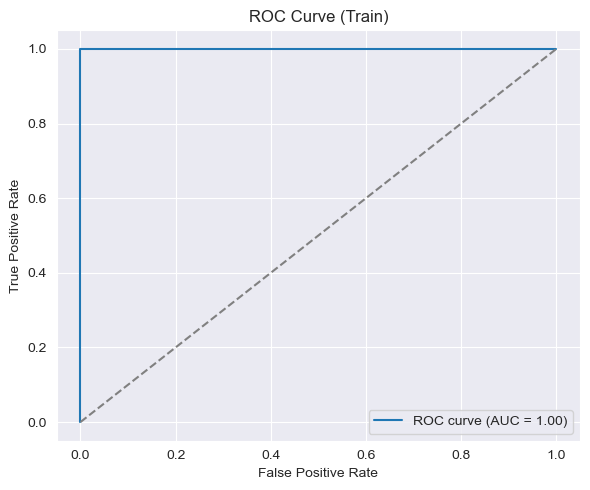

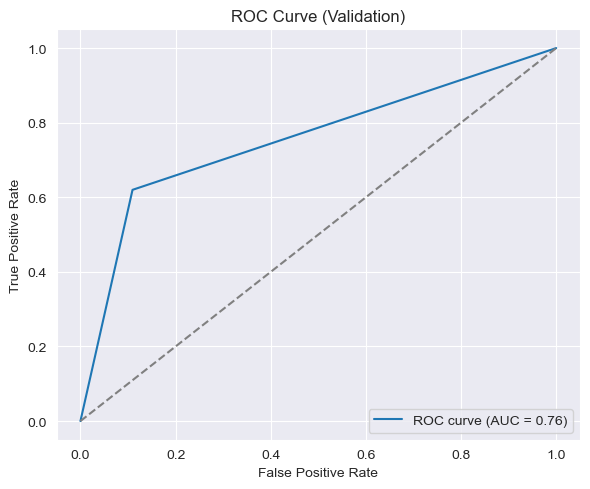

In [5]:
y_train_probs = tree.predict_proba(X_train)[:, 1]
y_train_pred = tree.predict(X_train)

y_val_probs = tree.predict_proba(X_val)[:, 1]
y_val_pred = tree.predict(X_val)

print_main_metrics(y_train, y_train_probs, y_train_pred, prefix="Train")
print_main_metrics(y_val, y_val_probs, y_val_pred, prefix="Validation")

plot_roc_curve(y_train, y_train_probs, title="ROC Curve (Train)")
plot_roc_curve(y_val, y_val_probs, title="ROC Curve (Validation)")

In [6]:
print(f"Tree depth: {tree.get_depth()}")

Tree depth: 26


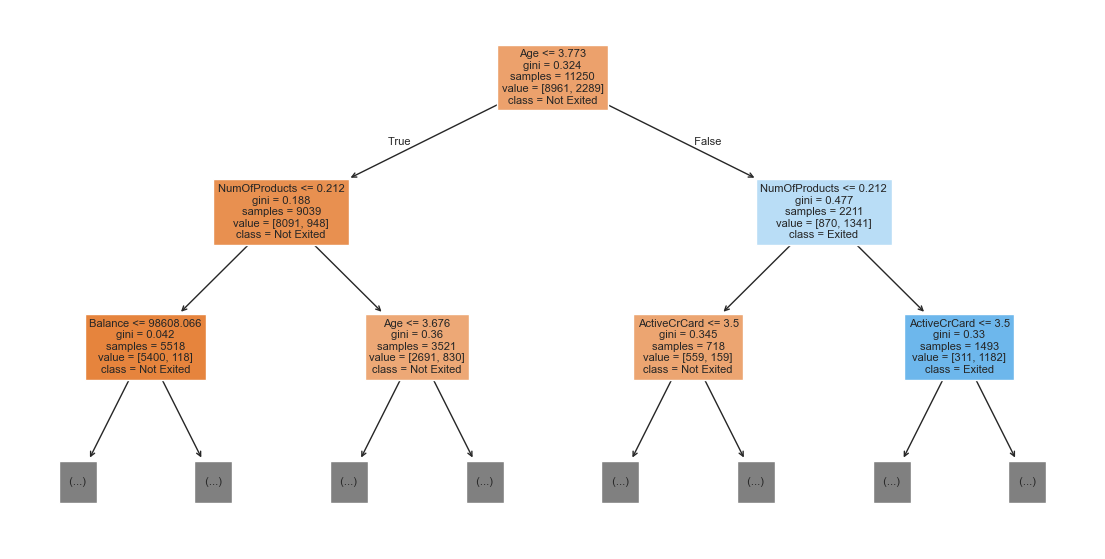

In [7]:
plt.figure(figsize=(14, 7))
plot_tree(tree, max_depth=2, feature_names=X_train.columns, class_names=["Not Exited", "Exited"], filled=True)
plt.show()

              feature  importance
17                Age    0.350088
12      NumOfProducts    0.140634
2     EstimatedSalary    0.120445
0         CreditScore    0.110595
1             Balance    0.080550
16         TenureAgeR    0.063514
15       ActiveCrCard    0.044466
3              Tenure    0.026108
8   NumOfProducts_1.0    0.014825
14          Geography    0.010263


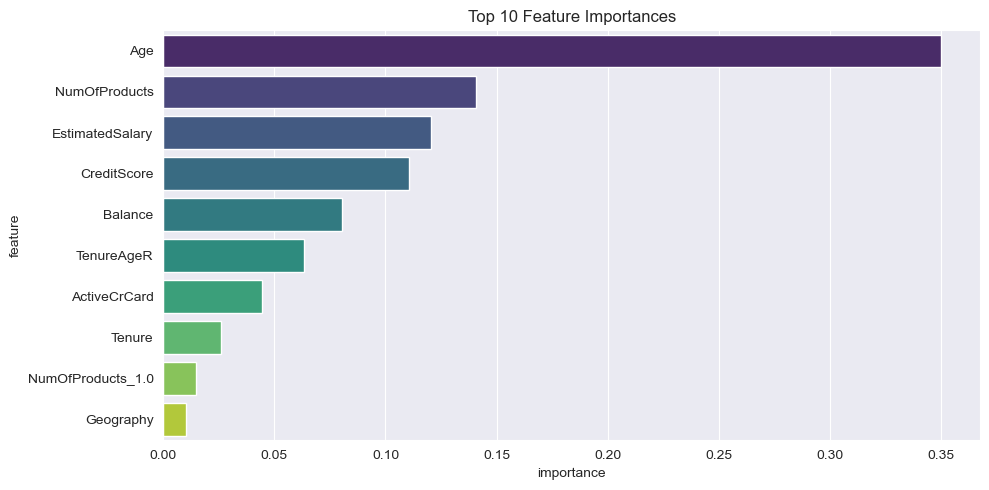

In [8]:
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": tree.feature_importances_
}).sort_values(by="importance", ascending=False)

print(importance_df.head(10))

plot_feature_importances(importance_df, top_n=10, title="Top 10 Feature Importances")

# Summary

## Model Training

A **Decision Tree Classifier** was trained using default hyperparameters and `random_state=42`.
The resulting tree depth was **26**, indicating a highly complex model.

## Metrics

- **Train AUROC**: 1.000
- **Train F1**: 1.000
- **Validation AUROC**: 0.755
- **Validation F1**: 0.605

These perfect metrics on the training set clearly indicate **strong overfitting**, since the performance drops significantly on the validation set.

## Tree Visualization (depth ≤ 2)

When visualizing the tree up to depth 2, the most important features used in the first splits are:

- **NumOfProducts**
- **Age**
- **Balance**
- **ActiveCrCard**

This means these features are the most influential in early decision points.

## Feature Importances

According to the feature importance plot, the top features are:

1. Age
2. NumOfProducts
3. EstimatedSalary
4. CreditScore
5. Balance
6. TenureAgeR
7. ActiveCrCard
8. Tenure
9. NumOfProducts_1.0
10. Geography

Age and NumOfProducts have the highest importance and play a crucial role in the model's decisions.

**Завдання 3**. Спробуйте знайти такі параметри моделі `DecisionTree` аби модель генералізувала ліпше (був вищий показник AUROC на валідаційній вибірці). Проекспериментуйте з різними значеннями параметрів `max_leaf_nodes`, `max_depth` та лишіть ті, які дають найкращий результат, разом з відповідними AUROC на тренувальній і валідаційній вибірках.

В цьому завданні спробуйте просто знайти параметри методом "тика" :)

In [9]:
max_depth_values = [2, 3, 4, 5, 6, 8, 10, 15]
max_leaf_nodes_values = [None, 5, 10, 20, 30, 50, 100]

def grid_search_decision_tree(
    X_train,
    y_train,
    X_val,
    y_val,
    max_depth_values,
    max_leaf_nodes_values
):
    results = []

    for max_depth in max_depth_values:
        for max_leaf_nodes in max_leaf_nodes_values:
            tree = DecisionTreeClassifier(
                random_state=42,
                max_depth=max_depth,
                max_leaf_nodes=max_leaf_nodes
            )
            tree.fit(X_train, y_train)

            y_train_probs = tree.predict_proba(X_train)[:, 1]
            y_val_probs = tree.predict_proba(X_val)[:, 1]
            y_train_pred = tree.predict(X_train)
            y_val_pred = tree.predict(X_val)

            # Use updated silent version
            train_metrics = print_main_metrics(y_train, y_train_probs, y_train_pred, prefix="", silent=True)
            val_metrics = print_main_metrics(y_val, y_val_probs, y_val_pred, prefix="", silent=True)

            results.append({
                "max_depth": max_depth,
                "max_leaf_nodes": max_leaf_nodes,
                "train_auc": train_metrics["auc"],
                "val_auc": val_metrics["auc"]
            })

    results_df = pd.DataFrame(results)
    return results_df.sort_values(by="val_auc", ascending=False)

results_df = grid_search_decision_tree(X_train, y_train, X_val, y_val, max_depth_values, max_leaf_nodes_values)
print(results_df.head(10))

    max_depth  max_leaf_nodes  train_auc   val_auc
32          6            30.0   0.924058  0.923539
54         15            50.0   0.930630  0.921189
47         10            50.0   0.930630  0.921189
40          8            50.0   0.930809  0.921115
28          6             NaN   0.932759  0.920511
34          6           100.0   0.932759  0.920300
53         15            30.0   0.920461  0.920024
46         10            30.0   0.920461  0.920024
33          6            50.0   0.929458  0.919617
52         15            20.0   0.916217  0.919472


Best parameters: max_depth = 6, max_leaf_nodes = 30


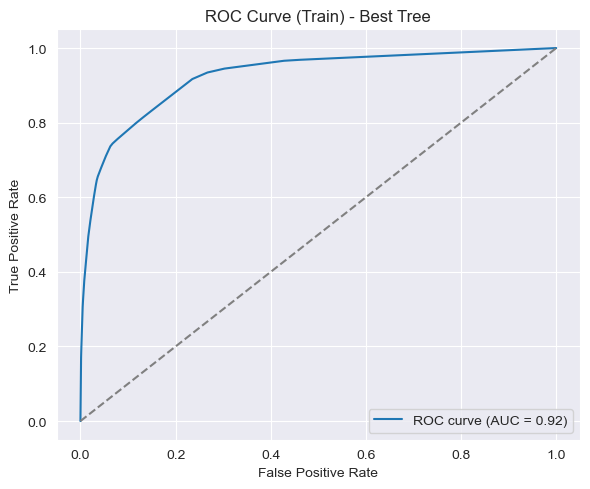

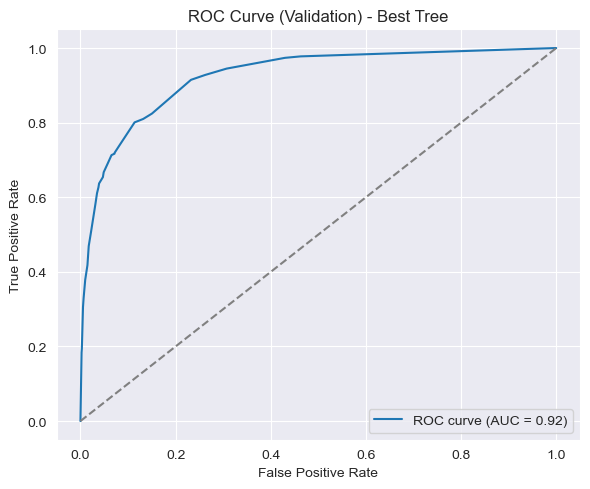

In [10]:
best_params = results_df.iloc[0]

best_max_depth = int(best_params["max_depth"]) if pd.notna(best_params["max_depth"]) else None
best_max_leaf_nodes = int(best_params["max_leaf_nodes"]) if pd.notna(best_params["max_leaf_nodes"]) else None

print(f"Best parameters: max_depth = {best_max_depth}, max_leaf_nodes = {best_max_leaf_nodes}")

best_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=best_max_depth,
    max_leaf_nodes=best_max_leaf_nodes
)
best_tree.fit(X_train, y_train)

y_train_probs = best_tree.predict_proba(X_train)[:, 1]
y_val_probs = best_tree.predict_proba(X_val)[:, 1]

plot_roc_curve(y_train, y_train_probs, title="ROC Curve (Train) - Best Tree")
plot_roc_curve(y_val, y_val_probs, title="ROC Curve (Validation) - Best Tree")

# Summary

## Objective

The goal was to find optimal hyperparameters for the `DecisionTreeClassifier` (`max_depth` and `max_leaf_nodes`) to improve generalization and achieve a higher AUROC on the validation set.

## Parameters Grid

- **max_depth**: [2, 3, 4, 5, 6, 8, 10, 15]
- **max_leaf_nodes**: [None, 5, 10, 20, 30, 50, 100]

All combinations were evaluated using a simple grid search approach.

## Best Parameters

- **max_depth**: 6
- **max_leaf_nodes**: 30

## Metrics

- **Train AUROC**: 0.924
- **Validation AUROC**: 0.924

Compared to the initial fully grown tree (AUROC ~0.75 on validation), this configuration significantly reduced overfitting and provided much better generalization.

## ROC Curve Analysis

The ROC curves for both training and validation sets are smooth and closely aligned, indicating good balance between fitting and generalization.
Unlike the previous overfitted tree, the curves are no longer "square-shaped", which suggests a lower risk of overfitting.


**Завдання 4**. В циклі пройдіться по значенням max_depth від 1 до 20 включно, на кожній ітерації натренуйте DecisionTree модель і виміряйте AUROC на трейн і валідаційних даних.

В кінці виведіть на графік залеєність між AUROC на трейн і валідаційних даних і номером ітерації.

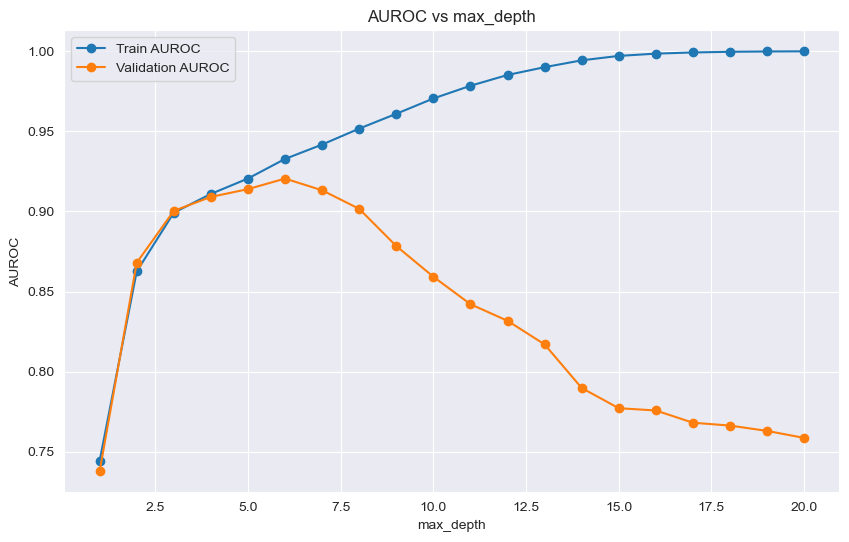

In [11]:
max_depth_values = list(range(1, 21))
max_leaf_nodes_values = [None]

results_df = grid_search_decision_tree(X_train, y_train, X_val, y_val, max_depth_values, max_leaf_nodes_values)

plot_df = results_df.sort_values(by="max_depth")

plt.figure(figsize=(10, 6))
plt.plot(plot_df["max_depth"], plot_df["train_auc"], marker='o', label="Train AUROC")
plt.plot(plot_df["max_depth"], plot_df["val_auc"], marker='o', label="Validation AUROC")
plt.xlabel("max_depth")
plt.ylabel("AUROC")
plt.title("AUROC vs max_depth")
plt.legend()
plt.grid(True)
plt.show()

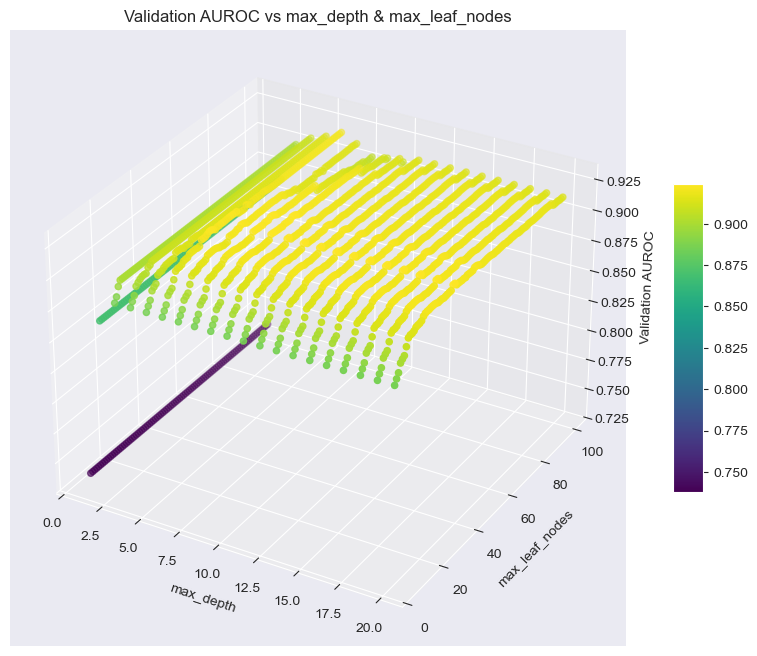

In [12]:
max_depth_values = list(range(1, 21))
max_leaf_nodes_values = list(range(5, 101))

results_df = grid_search_decision_tree(
    X_train, y_train, X_val, y_val,
    max_depth_values,
    max_leaf_nodes_values
)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

xs = results_df["max_depth"]
ys = results_df["max_leaf_nodes"]
zs = results_df["val_auc"]

sc = ax.scatter(xs, ys, zs, c=zs, cmap='viridis')

ax.set_xlabel("max_depth")
ax.set_ylabel("max_leaf_nodes")
ax.set_zlabel("Validation AUROC")
ax.set_title("Validation AUROC vs max_depth & max_leaf_nodes")

plt.colorbar(sc, ax=ax, shrink=0.5, aspect=10)

plt.show()

Best parameters: max_depth = 8, max_leaf_nodes = 44


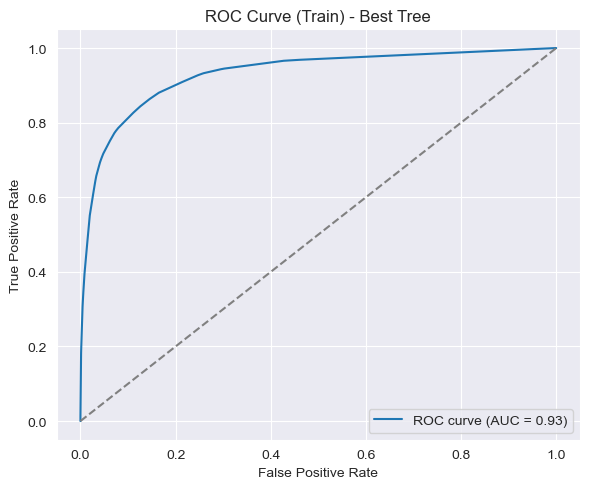

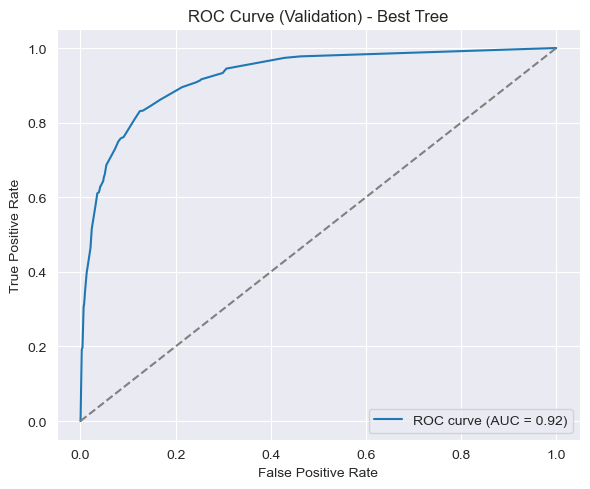

In [13]:
best_params = results_df.iloc[0]

best_max_depth = int(best_params["max_depth"]) if pd.notna(best_params["max_depth"]) else None
best_max_leaf_nodes = int(best_params["max_leaf_nodes"]) if pd.notna(best_params["max_leaf_nodes"]) else None

print(f"Best parameters: max_depth = {best_max_depth}, max_leaf_nodes = {best_max_leaf_nodes}")

best_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=best_max_depth,
    max_leaf_nodes=best_max_leaf_nodes
)
best_tree.fit(X_train, y_train)

y_train_probs = best_tree.predict_proba(X_train)[:, 1]
y_val_probs = best_tree.predict_proba(X_val)[:, 1]

plot_roc_curve(y_train, y_train_probs, title="ROC Curve (Train) - Best Tree")
plot_roc_curve(y_val, y_val_probs, title="ROC Curve (Validation) - Best Tree")

# Summary

## Objective

The aim was to analyze the effect of tree complexity on model performance by systematically varying `max_depth` and `max_leaf_nodes` hyperparameters. A grid search was conducted to evaluate how these parameters impact AUROC scores on both training and validation sets.

## Parameters

- **max_depth**: range from 1 to 20
- **max_leaf_nodes**: range from 5 to 100 with step 1

## AUROC Trends

When only `max_depth` was varied, it was observed that:
- The AUROC on the training set continuously increased with deeper trees.
- The AUROC on the validation set initially improved, peaked, and then gradually decreased, indicating overfitting at higher depths.

## 3D AUROC Surface

A detailed 3D plot of validation AUROC against `max_depth` and `max_leaf_nodes` revealed:
- There exists an optimal region where both hyperparameters balance model flexibility and generalization.
- Excessively large trees (high depth and many leaves) resulted in overfitting, as reflected by lower validation AUROC.

## Best Configuration

- **max_depth**: 8
- **max_leaf_nodes**: 44
- **Train AUROC**: 0.93
- **Validation AUROC**: 0.92

The corresponding ROC curves for this configuration confirmed robust separation between classes and strong generalization ability.


**Завдання 5**.
1. Натренуйте модель `DecisionTree` з найкращим значенням `max_depth`, яке ви знайшли на попередній ітерації.
2. Завантажте тестові дані змагання з `test.csv`.
3. Зробіть попередню обробку даних з функцією `preprocess_new_data` з вашого модуля `process_bank_churn.py`.
4. Зробіть передбачення використовуючи цю модель на тестових даних змагання.
5. Сформуйте `submission.csv`.
6. Зробіть новий Submission на Kaggle і додайте тут скріншот Вашого скору на паблік лідерборді :)


In [14]:
test_raw_df = pd.read_csv("../assets/hw_2_2/test.csv")

X_test_processed = preprocess_new_data(test_raw_df, preprocessor)

test_preds = best_tree.predict_proba(X_test_processed)[:, 1]

test_raw_df["Exited"] = test_preds

submission_df = pd.read_csv("../assets/hw_2_2/sample_submission.csv")

submission_df["Exited"] = test_raw_df["Exited"]

submission_df.to_csv("../assets/hw_2_3/submission_decision_tree_proba.csv", index=False)

display(submission_df.head())

,id,Exited
0,15000,0.058824
1,15001,0.014736
2,15002,0.014736
3,15003,0.663636
4,15004,0.014736


In [15]:
soft_params_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=3,
    max_leaf_nodes=30
)
soft_params_tree.fit(X_train, y_train)

X_test_processed = preprocess_new_data(test_raw_df, preprocessor)

test_preds = soft_params_tree.predict_proba(X_test_processed)[:, 1]

test_raw_df["Exited"] = test_preds

submission_df["Exited"] = test_raw_df["Exited"]

submission_df.to_csv("../assets/hw_2_3/submission_soft_params_tree_depth6_leaf30_proba.csv", index=False)

display(submission_df.head())

,id,Exited
0,15000,0.153646
1,15001,0.014736
2,15002,0.014736
3,15003,0.629174
4,15004,0.014736


In [16]:
drop_cols = ["id", "CustomerId", "Surname", "Exited"]

input_cols_all = [col for col in raw_df.columns if col not in drop_cols]

X_all = raw_df[input_cols_all]
y_all = raw_df["Exited"]

X_all_processed = preprocessor.transform(X_all)

final_soft_params_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=8,
    max_leaf_nodes=44
)
final_soft_params_tree.fit(X_all_processed, y_all)

X_test_processed = preprocess_new_data(test_raw_df, preprocessor)

test_preds = final_soft_params_tree.predict_proba(X_test_processed)[:, 1]

test_raw_df["Exited"] = test_preds
submission_df["Exited"] = test_raw_df["Exited"]

submission_df.to_csv("../assets/hw_2_3/submission_tree_full_train_depth8_leaf44_proba.csv", index=False)

display(submission_df.head())


C:\Users\Dmity\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


,id,Exited
0,15000,0.186842
1,15001,0.013561
2,15002,0.013561
3,15003,0.671329
4,15004,0.013561
